
# Snore vs Non‑Snore Classification — SVM + GridSearchCV (No YAMNet)

This notebook replicates your original data setup and **noise augmentation** pipeline, but **skips YAMNet**.  
It extracts **MFCC features** and trains an **SVM** classifier with **cross‑validation (GridSearchCV)**, then evaluates on both **clean** and **noisy** test sets.


In [ ]:

# Install dependencies
!pip install -q librosa soundfile noisereduce tqdm scikit-learn matplotlib seaborn kaggle


In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from google.colab import files
print("Upload your kaggle.json (from https://www.kaggle.com/settings/account).")
uploaded = files.upload()  # Upload kaggle.json when prompted

import os, shutil
assert 'kaggle.json' in uploaded, "Please upload kaggle.json"
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copyfile('kaggle.json', os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured.")


Mounted at /content/drive
Upload your kaggle.json (from https://www.kaggle.com/settings/account).


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [ ]:

# Create folders
!mkdir -p "/content/drive/MyDrive/snore_data"
!mkdir -p "/content/drive/MyDrive/noise_data"

# Download snoring dataset
!kaggle datasets download tareqkhanemu/snoring -p "/content/drive/MyDrive/snore_data" --unzip

# Download ESC-50 (concatenated class WAVs) noise
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "/content/drive/MyDrive/noise_data" --unzip


Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

import os

SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"   # snore
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"   # non-snore
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"         # ESC-50 concatenated WAVs

snore_ct = len([f for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')])
non_ct   = len([f for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')])
noise_ct = len([f for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')])

print("Snore files:", snore_ct)
print("Non-snore files:", non_ct)
print("Noise wavs:", noise_ct)
assert noise_ct > 0, "No noise wavs found — check NOISE_PATH"


Snore files: 500
Non-snore files: 500
Noise wavs: 2000


In [ ]:

import numpy as np
import librosa, random

# Collect available noise wavs
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]
assert len(noise_files) > 0, "No noise wavs found — check NOISE_PATH."

def mix_audio_with_noise(audio, noise, snr_db=10):
    """Add noise to audio at target SNR (dB)."""
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]

    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    """Load mono audio, pad/trim to target length, optionally add random noise at random SNR."""
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)


In [ ]:

def extract_mfcc_features(y, sr=16000, n_mfcc=40):
    """Return MFCC mean+std features -> shape (2 * n_mfcc,)"""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    return np.concatenate([mfcc_mean, mfcc_std])


In [ ]:

from sklearn.model_selection import train_test_split
snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

len(snore_files), len(non_files), len(X_tr_paths), len(X_te_paths)


(500, 500, 800, 200)

In [ ]:

from tqdm import tqdm

def features_from_paths(paths, add_noise=False):
    feats = []
    for p in tqdm(paths, desc=f"Extracting (add_noise={add_noise})"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0)
        feats.append(extract_mfcc_features(y))
    return np.stack(feats)

X_tr = features_from_paths(X_tr_paths, add_noise=True)   # AUGMENTED TRAIN
X_te = features_from_paths(X_te_paths, add_noise=False)  # CLEAN TEST
X_tr.shape, X_te.shape


Extracting (add_noise=False): 100%|██████████| 200/200 [00:38<00:00,  5.22it/s]


((800, 80), (200, 80))

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid = {
    'svm__C': [0.3, 1, 3, 10, 30, 100],
    'svm__gamma': ['scale', 0.001, 0.003, 0.01, 0.03, 0.1],
    'svm__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1
)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)
print("Best CV score (mean accuracy):", round(grid.best_score_, 4))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'svm__C': 10, 'svm__class_weight': None, 'svm__gamma': 'scale'}
Best CV score (mean accuracy): 0.825


In [ ]:

import pandas as pd
cvres = pd.DataFrame(grid.cv_results_).sort_values('mean_test_score', ascending=False)
display(cvres[['mean_test_score','std_test_score','param_svm__C','param_svm__gamma','param_svm__class_weight']].head(10))


,mean_test_score,std_test_score,param_svm__C,param_svm__gamma,param_svm__class_weight
42,0.82500,0.018957,10.0,scale,balanced
36,0.82500,0.018957,10.0,scale,None
63,0.82000,0.032452,100.0,0.01,None
51,0.82000,0.034551,30.0,0.01,None
69,0.82000,0.032452,100.0,0.01,balanced
57,0.82000,0.034551,30.0,0.01,balanced
39,0.81875,0.021287,10.0,0.01,None
54,0.81875,0.024044,30.0,scale,balanced
45,0.81875,0.021287,10.0,0.01,balanced
48,0.81875,0.024044,30.0,scale,None


=== Clean Test ===
              precision    recall  f1-score   support

           0     0.9000    0.9900    0.9429       100
           1     0.9889    0.8900    0.9368       100

    accuracy                         0.9400       200
   macro avg     0.9444    0.9400    0.9398       200
weighted avg     0.9444    0.9400    0.9398       200

ROC-AUC: 0.9910999999999999


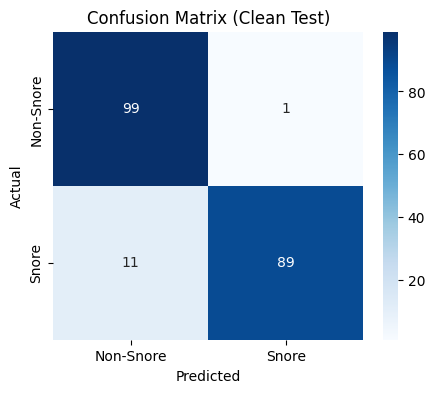

In [ ]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = grid.best_estimator_

probs = best_model.predict_proba(X_te)[:,1]
preds = best_model.predict(X_te)

print("=== Clean Test ===")
print(classification_report(y_te, preds, digits=4))
print("ROC-AUC:", roc_auc_score(y_te, probs))

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Snore','Snore'], yticklabels=['Non-Snore','Snore'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Clean Test)')
plt.show()


Extracting (add_noise=True): 100%|██████████| 200/200 [00:50<00:00,  3.93it/s]


=== Noisy Test ===
              precision    recall  f1-score   support

           0     0.8061    0.7900    0.7980       100
           1     0.7941    0.8100    0.8020       100

    accuracy                         0.8000       200
   macro avg     0.8001    0.8000    0.8000       200
weighted avg     0.8001    0.8000    0.8000       200

ROC-AUC (noisy): 0.8954


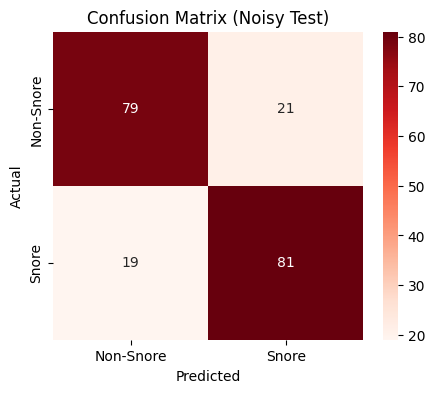

In [ ]:

X_te_noisy = features_from_paths(X_te_paths, add_noise=True)
probs_n = best_model.predict_proba(X_te_noisy)[:,1]
preds_n = best_model.predict(X_te_noisy)

print("=== Noisy Test ===")
print(classification_report(y_te, preds_n, digits=4))
print("ROC-AUC (noisy):", roc_auc_score(y_te, probs_n))

cm_n = confusion_matrix(y_te, preds_n)
plt.figure(figsize=(5,4))
sns.heatmap(cm_n, annot=True, fmt='d', cmap='Reds', xticklabels=['Non-Snore','Snore'], yticklabels=['Non-Snore','Snore'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Noisy Test)')
plt.show()


In [ ]:

import joblib, os
save_path = '/content/drive/MyDrive/snore_svm_best_model.joblib'
joblib.dump(best_model, save_path)
print(f'Model saved to: {save_path}')


Model saved to: /content/drive/MyDrive/snore_svm_best_model.joblib
